# Integrable deformations of kaleidocycles

Companion codes for the paper "Integrable deformations of Kaleidocycles" by Shizuo KAJI, Satoshi KAWAKUBO, Nozomu MATSUURA, and Shota SHIGETOMI, in preparation.

1. reconstruct a closed anti-oriented kaleidocycle in curvature coordinates
2. evaluate arbitrary positive semi-discrete mKdV hierarchy fields
3. construct the spectral integrals from the twisted monodromy and the corresponding hierarchy Hamiltonians
4. verify the Hamiltonian identities, conservation laws, closure, frame monodromy, and constant torsion numerically
5. compare the general hierarchy implementation with the previous explicit first and second flows
6. count the independent hierarchy directions from the orbit Jacobian and spectral curve

## Setup

We use the curvature coordinates

$$
z_n=\frac{\kappa_n}{2}=\tan\frac{\phi_n}{2},\qquad
D_n=1+z_n^2,
$$

with the twisted boundary condition $x_{n+N}=\sigma x_n$. The positive hierarchy starts from

$$
K^{(1)}=P(z)(z_1-z_{-1}),\qquad P(z)=1+z^2,
$$

and $K^{(j+1)}=\mathscr R_0K^{(j)}$. The implementation evaluates the equivalent Hamiltonian construction from the twisted Floquet multiplier. 

In [1]:
%matplotlib widget
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

notebook_dir = Path(".") if Path("output").is_dir() else Path("notebooks")

from kaleidocycle import (
    Kaleidocycle,
    critical_multiplier,
    critical_torsion_cosine,
    curvature_angles,
    curvature_weights,
    framed_polygon_from_binormals,
    hierarchy_hamiltonian_gradients,
    hierarchy_hamiltonians,
    hierarchy_orbit_jacobian,
    import_json,
    integrate_curvature_flow,
    lift_coefficients,
    load_sample,
    mkdv1_field,
    mkdv2_field,
    mkdv_hierarchy_field,
    plot_band,
    qrt_invariant,
    rotation_1,
    rotation_3,
    second_hamiltonian,
    sine_gordon_field,
    spectral_integrals,
    spectral_curve_diagnostics,
    variational_recurrence_residual,
)

plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 110})

## Steps

### 1. Extract curvature coordinates from a closed cycle

The source contains $N+1$ binormals, including the terminal signed copy. Extraction validates unit directions, constant adjacent inner products, and endpoint monodromy.

In [2]:
data_path = notebook_dir / "output/kaleidocycle_k8_nonoriented_bending.json"
cycle = import_json(data_path)
initial = framed_polygon_from_binormals(cycle.hinges)

print(f"N = {initial.curvatures.size}, sign = {initial.sign}")
print(f"torsion angle mu = {initial.torsion_angle:.12f}")
print(f"torsion cosine  = {np.cos(initial.torsion_angle):.3e}")
print(f"closure residual = {np.linalg.norm(initial.closure_residual):.3e}")
print(f"monodromy residual = {np.linalg.norm(initial.monodromy_residual):.3e}")

N = 8, sign = -1
torsion angle mu = 1.081552082273
torsion cosine  = 4.700e-01
closure residual = 3.388e-16
monodromy residual = 0.000e+00


### 2. Construct the positive hierarchy and conserved quantities

With

$$
\mathsf U_n(\zeta)=\frac{1}{\sqrt{P(z_n)}}
\begin{pmatrix}\zeta&\zeta^{-1}z_n\\-\zeta z_n&\zeta^{-1}\end{pmatrix},
\qquad
\Delta_\sigma=\operatorname{tr}(\mathsf J_\sigma\mathsf T_n),
$$

let $\rho_\sigma$ be the Floquet branch with leading term $\zeta^N e^{-\mathcal E_1/2}$. The spectral integrals are defined by

$$
-2\log\frac{\rho_\sigma(\zeta)}{\zeta^N}
=\sum_{m\geq0}\mathcal I_{m+1}\zeta^{-2m}.
$$

The Hamiltonian of the $(m+1)$-st positive flow is the paper's Chebyshev/binomial combination

$$
\mathcal E_{m+1}
=\sum_{k=0}^{\lfloor(m-1)/2\rfloor}\binom{m}{k}
\mathcal I_{m-2k+1}
+\mathbf 1_{m\text{ even}}\binom{m}{m/2}\mathcal I_1.
$$

In [3]:
hierarchy_order = 5
kappa_0 = initial.curvatures
sigma = initial.sign

initial_integrals = spectral_integrals(kappa_0, hierarchy_order, sign=sigma)
initial_hamiltonians = hierarchy_hamiltonians(
    kappa_0, hierarchy_order, sign=sigma
)
hamiltonian_gradients = hierarchy_hamiltonian_gradients(
    kappa_0, hierarchy_order, sign=sigma
)
hierarchy_fields = np.array(
    [
        mkdv_hierarchy_field(kappa_0, order, sign=sigma)
        for order in range(1, hierarchy_order + 1)
    ]
)

print("order       I_j              E_j          ||X^(j)||")
for order, (integral, hamiltonian, field) in enumerate(
    zip(initial_integrals, initial_hamiltonians, hierarchy_fields), start=1
):
    print(
        f"{order:>3d}  {integral: .10e}  {hamiltonian: .10e}  "
        f"{np.linalg.norm(field):.3e}"
    )

print("\nGeneral/explicit comparison")
print(
    "X1 error:",
    np.linalg.norm(
        hierarchy_fields[0] - mkdv1_field(kappa_0, sign=sigma), ord=np.inf
    ),
)
print(
    "X2 error:",
    np.linalg.norm(
        hierarchy_fields[1] - mkdv2_field(kappa_0, sign=sigma), ord=np.inf
    ),
)
print(
    "max |dE_i(X_j)|:",
    np.max(np.abs(hamiltonian_gradients @ hierarchy_fields.T)),
)

order       I_j              E_j          ||X^(j)||
  1   2.8364888647e+00   2.8364888647e+00  4.382e+00
  2   2.8615810074e+00   2.8615810074e+00  5.686e+00
  3  -4.8535747264e+00   8.1940300309e-01  2.742e-02
  4  -1.2557553779e+01  -3.9728107570e+00  1.904e+01
  5  -6.7606670441e+00  -9.1560327612e+00  4.335e+01

General/explicit comparison
X1 error: 0.0
X2 error: 0.0
max |dE_i(X_j)|: 2.1491223522262903e-14


### 3. Integrate positive and negative flows

The positive fields accept any name `mkdvN` (or the integer order). We integrate the first three positive flows and, in the anti-periodic sector, the sine--Gordon negative flow. Each sampled curvature vector is reconstructed using the same initial frame.

In [4]:
times = np.linspace(0.0, 0.5, 51)
flow_names = ("mkdv1", "mkdv2", "mkdv3", "sine-gordon")
evolutions = {
    name: integrate_curvature_flow(
        initial.curvatures,
        initial.torsion_angle,
        times,
        flow=name,
        sign=initial.sign,
        initial_frame=initial.frames[0],
    )
    for name in flow_names
}

for name, evolution in evolutions.items():
    print(name, evolution.curvatures.shape)

mkdv1 (51, 8)
mkdv2 (51, 8)
mkdv3 (51, 8)
sine-gordon (51, 8)


### 4. Verify the full set of conservation laws and global constraints

Every positive flow preserves every $\mathcal I_i$ and $\mathcal E_i$. On the anti-periodic space, the sine--Gordon flow preserves them as well. The lift also implies preservation of closure and frame monodromy.

In [5]:
integral_histories = {}
hamiltonian_histories = {}
diagnostics = {}
for name, evolution in evolutions.items():
    configurations = evolution.configurations()
    integral_history = evolution.spectral_integrals(hierarchy_order)
    hamiltonian_history = evolution.hierarchy_hamiltonians(hierarchy_order)
    integral_histories[name] = integral_history
    hamiltonian_histories[name] = hamiltonian_history
    diagnostics[name] = {
        "max I drift": np.max(np.ptp(integral_history, axis=0)),
        "max E drift": np.max(np.ptp(hamiltonian_history, axis=0)),
        "max closure": max(
            np.linalg.norm(c.closure_residual) for c in configurations
        ),
        "max monodromy": max(
            np.linalg.norm(c.monodromy_residual) for c in configurations
        ),
        "max torsion error": max(
            np.max(
                np.abs(
                    np.einsum(
                        "ij,ij->i", c.binormals[:-1], c.binormals[1:]
                    )
                    - np.cos(c.torsion_angle)
                )
            )
            for c in configurations
        ),
    }

for name, values in diagnostics.items():
    print(
        f"{name:12s} "
        + "  ".join(f"{key}={value:.2e}" for key, value in values.items())
    )

mkdv1        max I drift=1.15e-09  max E drift=1.38e-09  max closure=5.17e-10  max monodromy=7.70e-10  max torsion error=5.00e-16
mkdv2        max I drift=2.86e-09  max E drift=3.44e-09  max closure=3.59e-10  max monodromy=5.25e-10  max torsion error=4.44e-16
mkdv3        max I drift=3.29e-14  max E drift=3.91e-14  max closure=5.67e-14  max monodromy=5.16e-14  max torsion error=4.44e-16
sine-gordon  max I drift=5.29e-10  max E drift=6.36e-10  max closure=3.26e-10  max monodromy=2.60e-10  max torsion error=4.44e-16


### 5. Check the general hierarchy lift

For every positive order we construct local moving-frame coefficients $w_n^{(j)}$ and $v_n^{(j)}=\partial_\mu w_n^{(j)}$. They must satisfy

$$
w_{n+1}=L_{n+1}^{\mathsf T}w_n+\frac{X_{n+1}^{(j)}}{D_{n+1}}e_3,
\qquad
\Omega(w_n)e_1=L_{n+1}v_{n+1}-v_n.
$$

We check these relations for the third-order lift.

In [6]:
lift_order = 3
coefficients = lift_coefficients(
    kappa_0,
    initial.torsion_angle,
    flow=f"mkdv{lift_order}",
    sign=sigma,
)
field = mkdv_hierarchy_field(kappa_0, lift_order, sign=sigma)
angles = curvature_angles(kappa_0)
weights = curvature_weights(kappa_0)
angular_residuals = []
vertex_residuals = []

for n in range(kappa_0.size - 1):
    transition = rotation_1(initial.torsion_angle) @ rotation_3(angles[n + 1])
    expected_angular = (
        transition.T @ coefficients.angular[n]
        + np.array([0.0, 0.0, field[n + 1] / weights[n + 1]])
    )
    omega_e1 = np.array(
        [0.0, coefficients.angular[n, 2], -coefficients.angular[n, 1]]
    )
    angular_residuals.append(
        np.linalg.norm(coefficients.angular[n + 1] - expected_angular)
    )
    vertex_residuals.append(
        np.linalg.norm(
            transition @ coefficients.vertex[n + 1]
            - coefficients.vertex[n]
            - omega_e1
        )
    )

print(f"max zero-curvature residual: {max(angular_residuals):.3e}")
print(f"max velocity residual: {max(vertex_residuals):.3e}")

max zero-curvature residual: 4.148e-15
max velocity residual: 2.331e-15


### 6. Critical locus of the torsion

On the Lagrange-critical locus of the projection to the torsion variable,

$$
D_n(\kappa_{n-1}+\kappa_{n+1})=\lambda\kappa_n,
\qquad
\lambda=2\cos\mu+\frac{\mathcal E_2}{N}.
$$

On this locus, every positive hierarchy field and the sine--Gordon field is either zero or a constant multiple of $X^{(1)}$. We measure those multipliers by least squares.

In [7]:
critical_cosine = critical_torsion_cosine(kappa_0, sign=sigma)
second_energy = second_hamiltonian(kappa_0, sign=sigma)
multiplier = critical_multiplier(kappa_0, critical_cosine, sign=sigma)
recurrence_error = np.linalg.norm(
    variational_recurrence_residual(kappa_0, multiplier, sign=sigma),
    ord=np.inf,
)
qrt_drift = np.ptp(qrt_invariant(kappa_0, multiplier, sign=sigma))

first_field = hierarchy_fields[0]
first_norm_squared = np.dot(first_field, first_field)
print(f"critical c: {critical_cosine:.6e}")
print(f"geometric c: {np.cos(initial.torsion_angle):.6e}")
print(f"lambda: {multiplier:.6e}")
print(f"recurrence residual: {recurrence_error:.3e}")
print(f"QRT drift: {qrt_drift:.3e}")
print("\nfield       multiplier        residual")
for order, candidate in enumerate(hierarchy_fields, start=1):
    scale = np.dot(first_field, candidate) / first_norm_squared
    residual = np.linalg.norm(candidate - scale * first_field, ord=np.inf)
    print(f"X^{order:<2d}   {scale: .8e}   {residual:.3e}")

sg_field = sine_gordon_field(kappa_0, initial.torsion_angle, sign=sigma)
sg_scale = np.dot(first_field, sg_field) / first_norm_squared
sg_residual = np.linalg.norm(sg_field - sg_scale * first_field, ord=np.inf)
print(f"sG    {sg_scale: .8e}   {sg_residual:.3e}")

critical c: 4.699588e-01
geometric c: 4.699589e-01
lambda: 1.297615e+00
recurrence residual: 8.295e-07
QRT drift: 3.241e-07

field       multiplier        residual
X^1     1.00000000e+00   0.000e+00
X^2     1.29761546e+00   1.576e-07
X^3     6.25827854e-03   7.076e-08
X^4    -4.34550279e+00   1.246e-07
X^5    -9.89153643e+00   9.024e-07
sG    -5.40377424e-01   2.273e-08


### 7. Off the critical locus; independent commuting motions

The bending-energy minimizer above lies on the critical locus, where the hierarchy
fields collapse to one direction. We now load another closed, constant-torsion
anti-oriented cycle for which the variational recurrence does not hold. We measure

$$
\frac{\min_a\|X^{(2)}-aX^{(1)}\|}{\|X^{(2)}\|}>0
$$

and check the commuting-flow identity

$$
\Phi_2^s\circ\Phi_1^t=\Phi_1^t\circ\Phi_2^s
$$

numerically. Thus the two flows give genuinely independent motions while preserving
closure and constant torsion.

relative recurrence residual: 7.259e+00
relative independence residual: 2.614e-01
relative commuting error: 2.367e-13
max closure residual: 1.138e-14
max torsion error: 2.949e-16


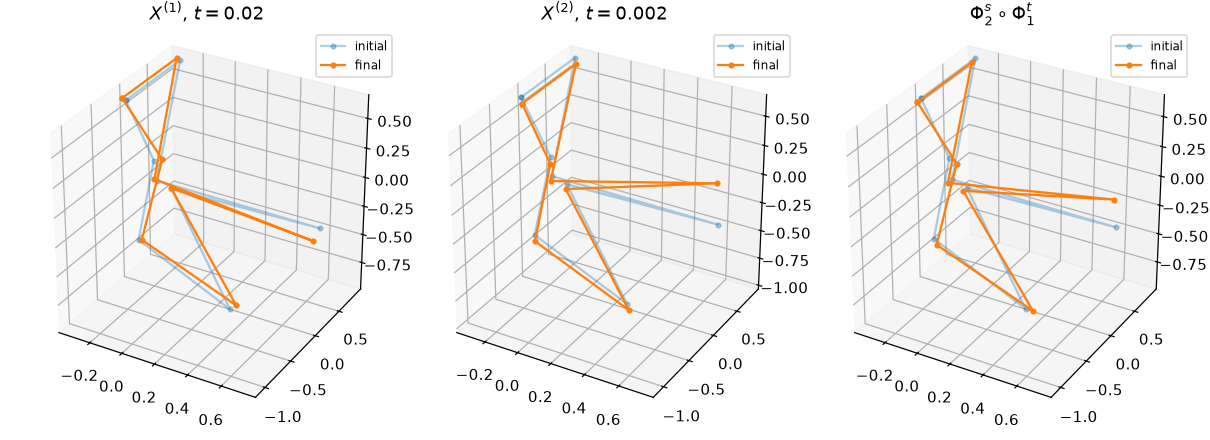

In [8]:
off_data_path = (
    notebook_dir / "output/kaleidocycle_k8_nonoriented_curvature_recursion.json"
)
off_cycle = import_json(off_data_path)
off_initial = framed_polygon_from_binormals(off_cycle.hinges)
off_kappa = off_initial.curvatures
off_sigma = off_initial.sign

off_x1 = mkdv_hierarchy_field(off_kappa, 1, sign=off_sigma)
off_x2 = mkdv_hierarchy_field(off_kappa, 2, sign=off_sigma)
off_scale = np.dot(off_x1, off_x2) / np.dot(off_x1, off_x1)
independence_error = np.linalg.norm(off_x2 - off_scale * off_x1) / np.linalg.norm(
    off_x2
)
off_recurrence_error = np.linalg.norm(
    variational_recurrence_residual(off_kappa, sign=off_sigma)
) / np.linalg.norm(off_kappa)

flow_1_time = 2.0e-2
flow_2_time = 2.0e-3


def evolve_off_locus(curvatures, flow, duration):
    return integrate_curvature_flow(
        curvatures,
        off_initial.torsion_angle,
        [0.0, duration],
        flow=flow,
        sign=off_sigma,
        initial_frame=off_initial.frames[0],
        rtol=1e-12,
        atol=1e-14,
    )


off_flow_1 = evolve_off_locus(off_kappa, "mkdv1", flow_1_time)
off_flow_2 = evolve_off_locus(off_kappa, "mkdv2", flow_2_time)
off_flow_12 = evolve_off_locus(
    off_flow_1.curvatures[-1], "mkdv2", flow_2_time
)
off_flow_21 = evolve_off_locus(
    off_flow_2.curvatures[-1], "mkdv1", flow_1_time
)

off_kappa_12 = off_flow_12.curvatures[-1]
off_kappa_21 = off_flow_21.curvatures[-1]
commuting_error = np.linalg.norm(off_kappa_12 - off_kappa_21) / max(
    np.linalg.norm(off_kappa_12 - off_kappa),
    np.linalg.norm(off_kappa_21 - off_kappa),
)
off_configurations = [
    off_initial,
    off_flow_1.configuration(-1),
    off_flow_2.configuration(-1),
    off_flow_12.configuration(-1),
    off_flow_21.configuration(-1),
]
off_closure_error = max(
    np.linalg.norm(configuration.closure_residual)
    for configuration in off_configurations
)
off_torsion_error = max(
    np.max(
        np.abs(
            np.einsum(
                "ij,ij->i",
                configuration.binormals[:-1],
                configuration.binormals[1:],
            )
            - np.cos(configuration.torsion_angle)
        )
    )
    for configuration in off_configurations
)

print(f"relative recurrence residual: {off_recurrence_error:.3e}")
print(f"relative independence residual: {independence_error:.3e}")
print(f"relative commuting error: {commuting_error:.3e}")
print(f"max closure residual: {off_closure_error:.3e}")
print(f"max torsion error: {off_torsion_error:.3e}")

off_motions = {
    rf"$X^{{(1)}}$, $t={flow_1_time:g}$": off_flow_1.configuration(-1),
    rf"$X^{{(2)}}$, $t={flow_2_time:g}$": off_flow_2.configuration(-1),
    r"$\Phi_2^s\circ\Phi_1^t$": off_flow_12.configuration(-1),
}
off_figure = plt.figure(figsize=(11, 4))
for column, (name, final) in enumerate(off_motions.items(), start=1):
    axis = off_figure.add_subplot(1, len(off_motions), column, projection="3d")
    for vertices, label, alpha in (
        (off_initial.vertices, "initial", 0.35),
        (final.vertices, "final", 1.0),
    ):
        centered = vertices - vertices[:-1].mean(axis=0)
        axis.plot(*centered.T, marker="o", markersize=3, alpha=alpha, label=label)
    axis.set_title(name)
    axis.set_box_aspect((1, 1, 1))
    axis.legend(fontsize=8)
off_figure.tight_layout()

### 8. Count independent Hamiltonian flows for a generic K15

At a fixed point of the $N$-dimensional finite curvature space, the recursion
operator generates a Krylov sequence. Cayley--Hamilton therefore says that the
first $N$ fields contain its full pointwise span. For $N=15$ we form the orbit map

$$
\mathcal O(t_1,\ldots,t_{15})
=\Phi_{15}^{t_{15}}\circ\cdots\circ\Phi_1^{t_1}(\kappa),
\qquad
D\mathcal O(0)=\begin{bmatrix}X^{(1)}&\cdots&X^{(15)}\end{bmatrix},
$$

and compute the rank of this Jacobian after normalising its columns.

For the spectral check, put $\lambda=\zeta^2$ and write

$$
\Delta_\sigma(\zeta)=\lambda^{-N/2}P(\lambda),
\qquad
y^2=F(\lambda)=P(\lambda)^2-4\sigma\lambda^N.
$$

The degree-$30$ model has arithmetic genus $14$. Closure and frame monodromy give
two quadruple branch points and the factor

$$
C_\mu(\lambda)^4
=\left(\lambda^2-2\cos\mu\,\lambda+1\right)^4.
$$

After removing it, the square-free branch polynomial has degree $22$ and genus
$10$. The reciprocal mKdV involution has quotient genus $5$, so the hierarchy
linearises on a Prym variety of dimension $10-5=5$.

The non-critical configuration below is loaded from the shared
`data/kaleidocycles/` catalogue. The web studio therefore displays exactly the
same input as this Jacobian and spectral-curve calculation.

Cayley--Hamilton field bound: 15


relative critical-recurrence residual: 1.807e+00
orbit-Jacobian rank: 5
relative singular values:
[1.000e+00 7.611e-01 2.754e-01 1.792e-01 5.084e-02 5.659e-16 2.270e-16
 1.406e-16 7.799e-17 3.649e-17 3.553e-17 2.714e-17 2.204e-17 1.464e-17
 4.160e-18]
spectral arithmetic genus: 14
normalised spectral genus: 10
reciprocal quotient genus: 5
Prym dimension: 5
closed-curve factor residual: 3.406e-14
normalised branch-point separation: 5.450e-02


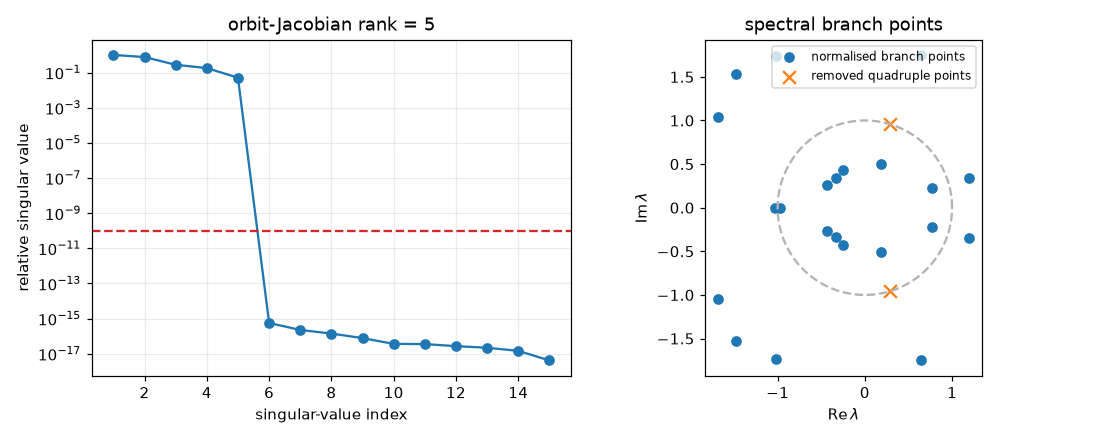

In [9]:
generic_k15 = load_sample("generic_k15_noncritical")
generic_k15_initial = framed_polygon_from_binormals(
    generic_k15.hinges, torsion_tolerance=1e-7
)
generic_k15_kappa = generic_k15_initial.curvatures
generic_k15_sigma = generic_k15_initial.sign

cayley_hamilton_bound = generic_k15_kappa.size
orbit_jacobian = hierarchy_orbit_jacobian(
    generic_k15_kappa,
    count=cayley_hamilton_bound,
    sign=generic_k15_sigma,
)
flow_norms = np.linalg.norm(orbit_jacobian, axis=0)
normalised_orbit_jacobian = orbit_jacobian / flow_norms
orbit_singular_values = np.linalg.svd(
    normalised_orbit_jacobian, compute_uv=False
)
relative_singular_values = orbit_singular_values / orbit_singular_values[0]
rank_tolerance = 1e-10
orbit_rank = int(np.sum(relative_singular_values > rank_tolerance))

generic_recurrence_error = np.linalg.norm(
    variational_recurrence_residual(
        generic_k15_kappa, sign=generic_k15_sigma
    )
) / np.linalg.norm(generic_k15_kappa)
spectral_curve = spectral_curve_diagnostics(
    generic_k15_kappa,
    sign=generic_k15_sigma,
    torsion_angle=generic_k15_initial.torsion_angle,
)

print(f"Cayley--Hamilton field bound: {cayley_hamilton_bound}")
print(f"relative critical-recurrence residual: {generic_recurrence_error:.3e}")
print(f"orbit-Jacobian rank: {orbit_rank}")
print("relative singular values:")
print(np.array2string(relative_singular_values, precision=3))
print(f"spectral arithmetic genus: {spectral_curve.arithmetic_genus}")
print(f"normalised spectral genus: {spectral_curve.geometric_genus}")
print(f"reciprocal quotient genus: {spectral_curve.quotient_genus}")
print(f"Prym dimension: {spectral_curve.prym_dimension}")
print(
    "closed-curve factor residual: "
    f"{spectral_curve.singular_factor_residual:.3e}"
)
print(
    "normalised branch-point separation: "
    f"{spectral_curve.minimum_root_separation:.3e}"
)

normalised_branch_points = np.roots(
    spectral_curve.normalised_branch_coefficients
)
removed_branch_points = np.exp(
    1j * np.array(
        [generic_k15_initial.torsion_angle, -generic_k15_initial.torsion_angle]
    )
)
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].semilogy(
    range(1, cayley_hamilton_bound + 1),
    relative_singular_values,
    marker="o",
)
axes[0].axhline(rank_tolerance, color="tab:red", linestyle="--")
axes[0].set(xlabel="singular-value index", ylabel="relative singular value")
axes[0].set_title(f"orbit-Jacobian rank = {orbit_rank}")
axes[0].grid(alpha=0.25)

unit_circle_angle = np.linspace(0.0, 2.0 * np.pi, 300)
axes[1].plot(
    np.cos(unit_circle_angle),
    np.sin(unit_circle_angle),
    color="0.7",
    linestyle="--",
)
axes[1].scatter(
    normalised_branch_points.real,
    normalised_branch_points.imag,
    label="normalised branch points",
)
axes[1].scatter(
    removed_branch_points.real,
    removed_branch_points.imag,
    marker="x",
    s=70,
    label="removed quadruple points",
)
axes[1].set(xlabel=r"$\operatorname{Re}\lambda$", ylabel=r"$\operatorname{Im}\lambda$")
axes[1].set_title("spectral branch points")
axes[1].set_aspect("equal")
axes[1].legend(fontsize=8)
figure.tight_layout()

### 9. Compare the resulting centre-line polygons

The curves are translated to their centroids only for display; reconstruction remains based at the original vertex and frame.

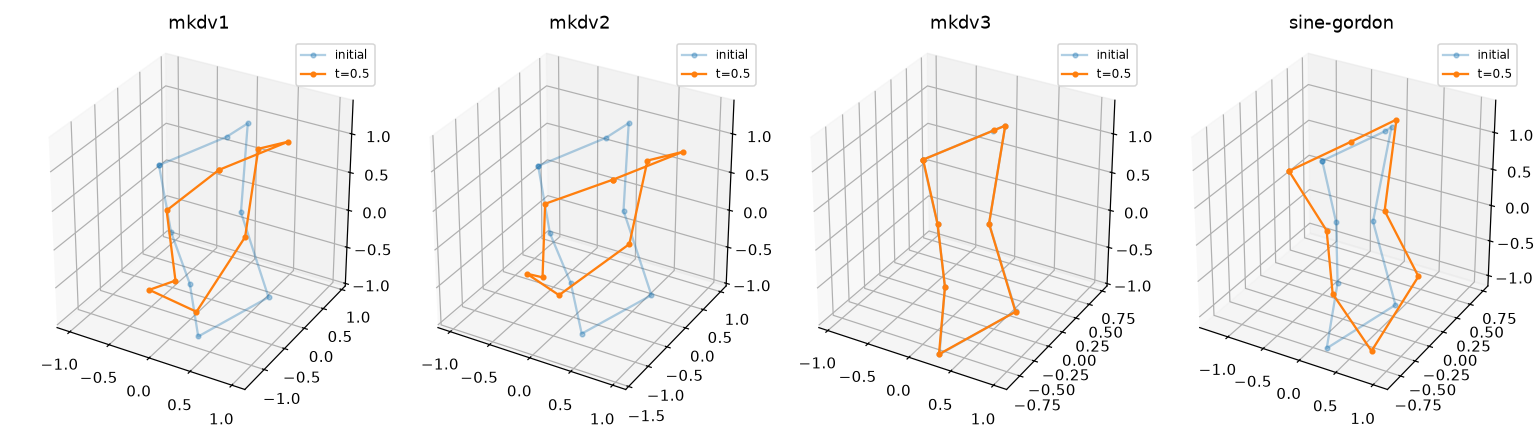

In [10]:
fig = plt.figure(figsize=(14, 4))
for column, name in enumerate(flow_names, start=1):
    axis = fig.add_subplot(1, len(flow_names), column, projection="3d")
    final = evolutions[name].configuration(-1)
    for vertices, label, alpha in (
        (initial.vertices, "initial", 0.35),
        (final.vertices, f"t={times[-1]:.1f}", 1.0),
    ):
        centered = vertices - vertices[:-1].mean(axis=0)
        axis.plot(*centered.T, marker="o", markersize=3, alpha=alpha, label=label)
    axis.set_title(name)
    axis.set_box_aspect((1, 1, 1))
    axis.legend(fontsize=8)
fig.tight_layout()

### 10. Animate an arbitrary hierarchy deformation

Set `animated_flow` to any computed flow below. The general API also accepts higher names such as `"mkdv4"`; integrate that flow first if it is not already in `evolutions`.

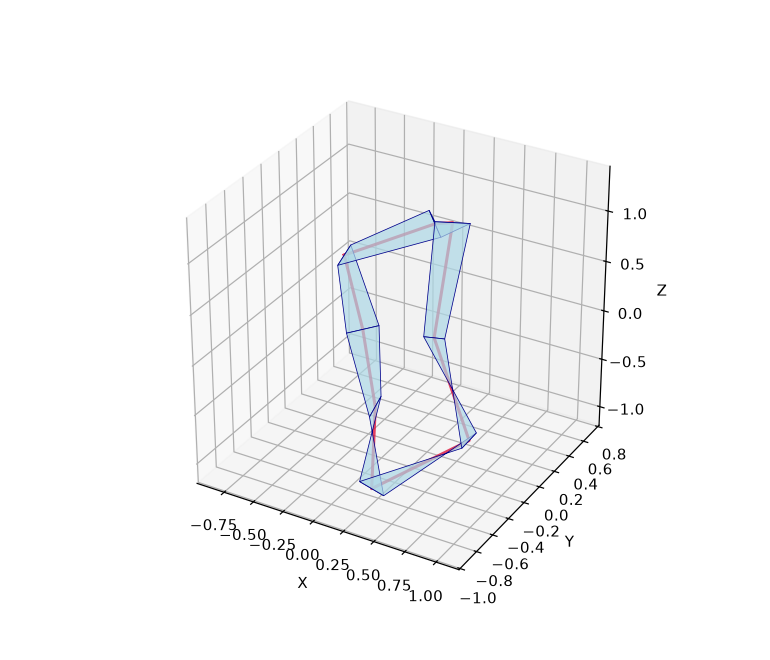

In [11]:
animated_flow = "mkdv3"
animation_configurations = evolutions[animated_flow].configurations()
animation_curves = [
    configuration.vertices - configuration.vertices[:-1].mean(axis=0)
    for configuration in animation_configurations
]
animation_hinges = [
    configuration.binormals for configuration in animation_configurations
]

animation_figure, deformation_animation = plot_band(
    curve=animation_curves,
    hinges=animation_hinges,
    title=f"{animated_flow} integrable deformation",
    show_curve=True,
    width=0.12,
    interval=70,
    figsize=(7, 6),
)
deformation_animation